In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [73]:
AMPLITUDE_LIST  = [0.07, 0.14, 0.21, 0.28, 0.35]
BETA_LIST       = [0.05, 0.1, 0.5, 1.0, 3.0, 10.0, 50.0]
PATH            = "../../data/raw/dynamic_resistances/sweep_amp_beta/"
data = {}

for amp in AMPLITUDE_LIST:
    data[amp] = {}
    for beta in BETA_LIST:
        df  = pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=2_amp{amp:.3f}_beta{beta:.2f}.csv")
        df  = df.drop(columns=['E1','G','Eq_Jumps','Jumps'])
        
        df['Total'] = df['Observable'] + df['Displacement']
        df['Resistance'] = pd.read_parquet(f"{PATH}resistances_Nx=9_Ny=9_Ne=2_amp{amp:.3f}_beta{beta:.2f}.parquet").mean(axis=1).values
        
        data[amp][beta] = df

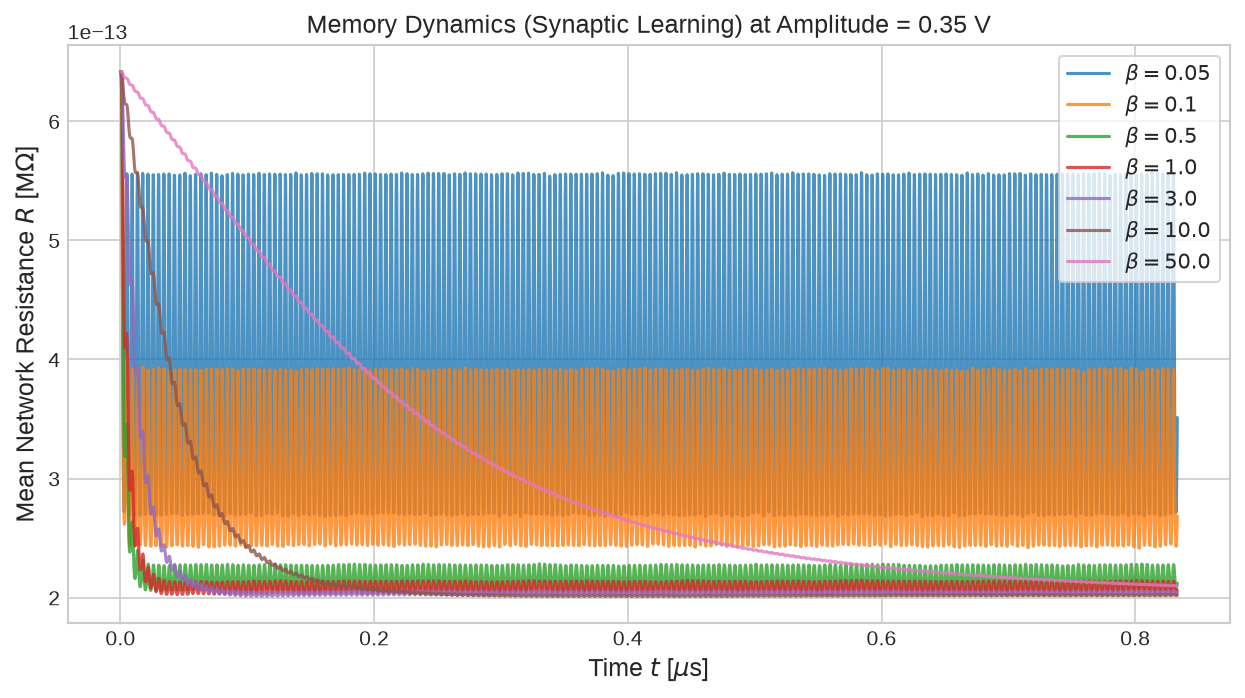

In [87]:
# Wir fixieren die höchste Amplitude (damit das Signal stark ist)
target_amp = 0.35
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# Iteriere durch verschiedene Betas, um das Gedächtnis zu vergleichen
colors = plt.cm.viridis(np.linspace(0, 1, len(plot_betas)))

for beta in BETA_LIST:
    df = data[target_amp][beta]
    # Konvertierung der Zeit in Mikrosekunden für eine saubere X-Achse
    time_us = df['t'].values * 1e6  
    ax.plot(time_us, df['Resistance'].values, label=rf"$\beta = {beta}$", alpha=0.8)

ax.set_xlabel(r"Time $t$ [$\mu$s]", size="large")
ax.set_ylabel(r"Mean Network Resistance $R$ [M$\Omega$]", size="large")
ax.set_title(f"Memory Dynamics (Synaptic Learning) at Amplitude = {target_amp} V")
ax.legend(frameon=True)
plt.show()

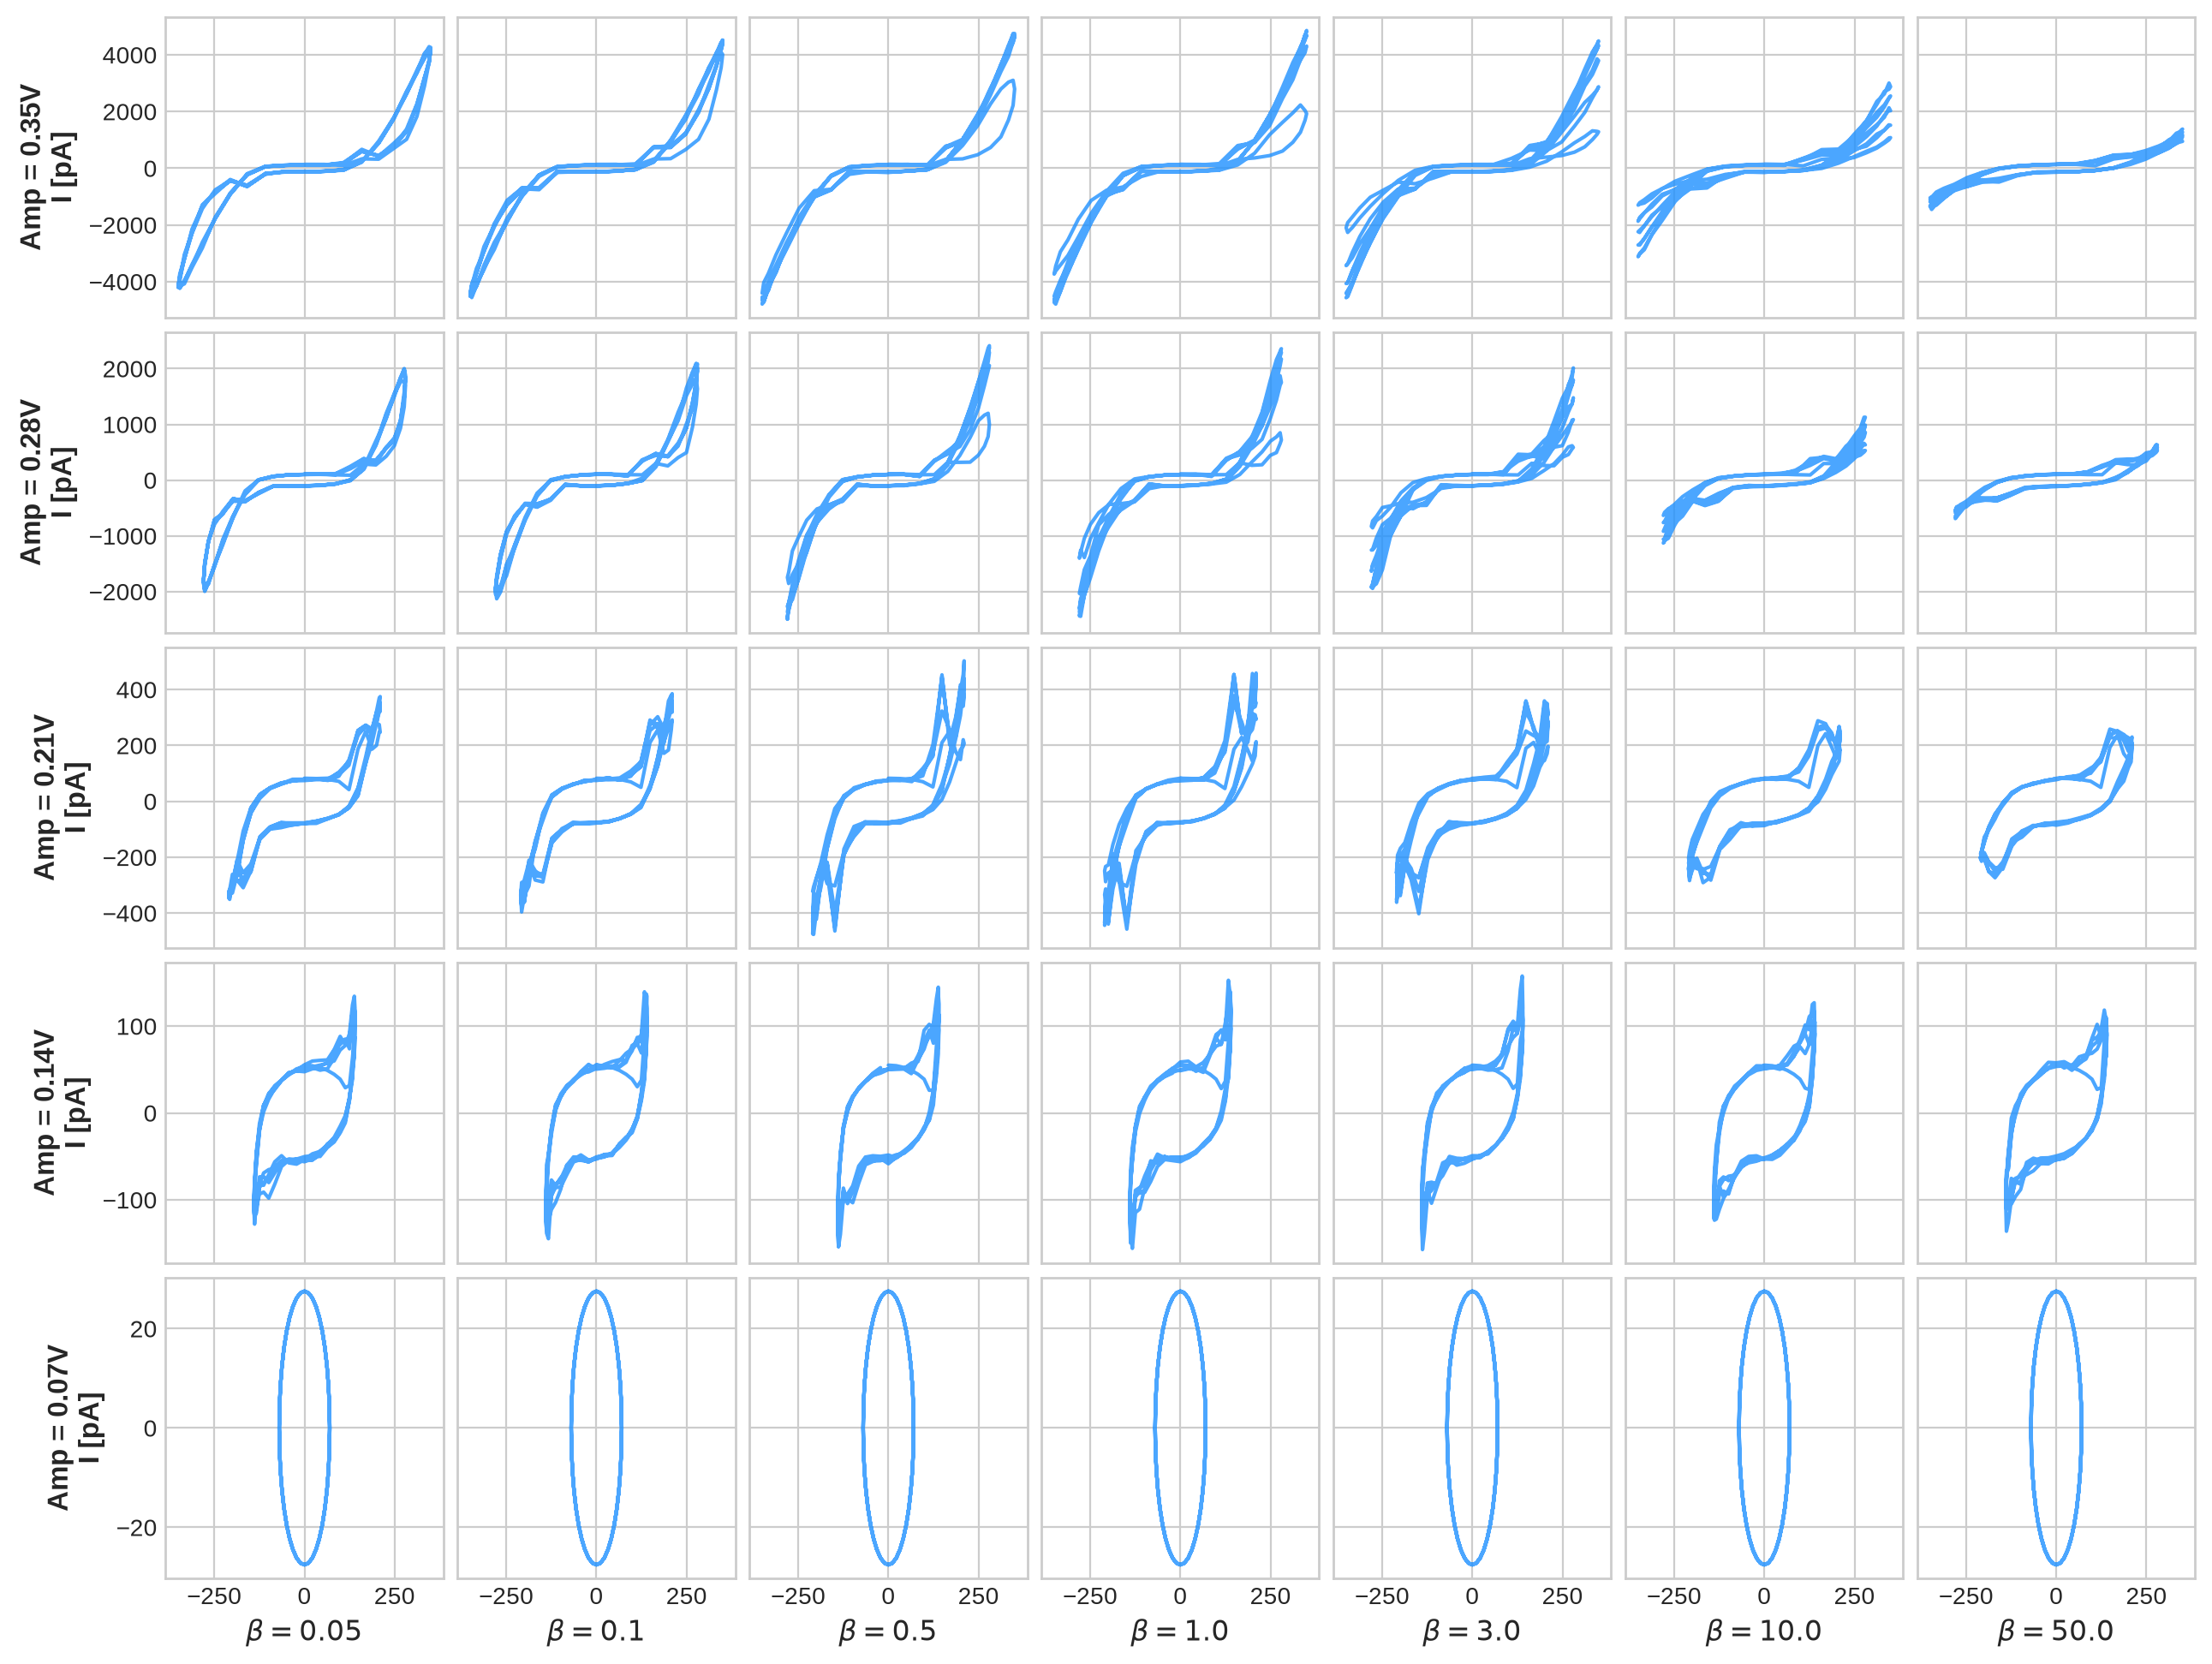

In [88]:
steps_per_period = 40
slice_start = 0*steps_per_period
slice_end = 5*steps_per_period

fig, axes = plt.subplots(
    len(AMPLITUDE_LIST), len(BETA_LIST), 
    dpi=200, sharex=True, sharey='row', layout='constrained'
)
fig.set_figwidth(fig.get_figwidth()*2)
fig.set_figheight(fig.get_figheight()*2)

for i, amp in enumerate(reversed(AMPLITUDE_LIST)):
    for j, beta in enumerate(BETA_LIST):
        ax = axes[i, j]
        df = data[amp][beta]
        
        V_last = df['E0'].values[slice_start:slice_end]*1000
        I_last = df['Total'].values[slice_start:slice_end]*1e-6
        
        ax.plot(V_last, I_last, color='dodgerblue', alpha=0.8)
        
        if i == len(AMPLITUDE_LIST) - 1:
            ax.set_xlabel(f"$\\beta = {beta}$", weight='bold', size='large')
        if j == 0:
            ax.set_ylabel(f"Amp = {amp}V\nI [pA]", weight='bold', size='large')

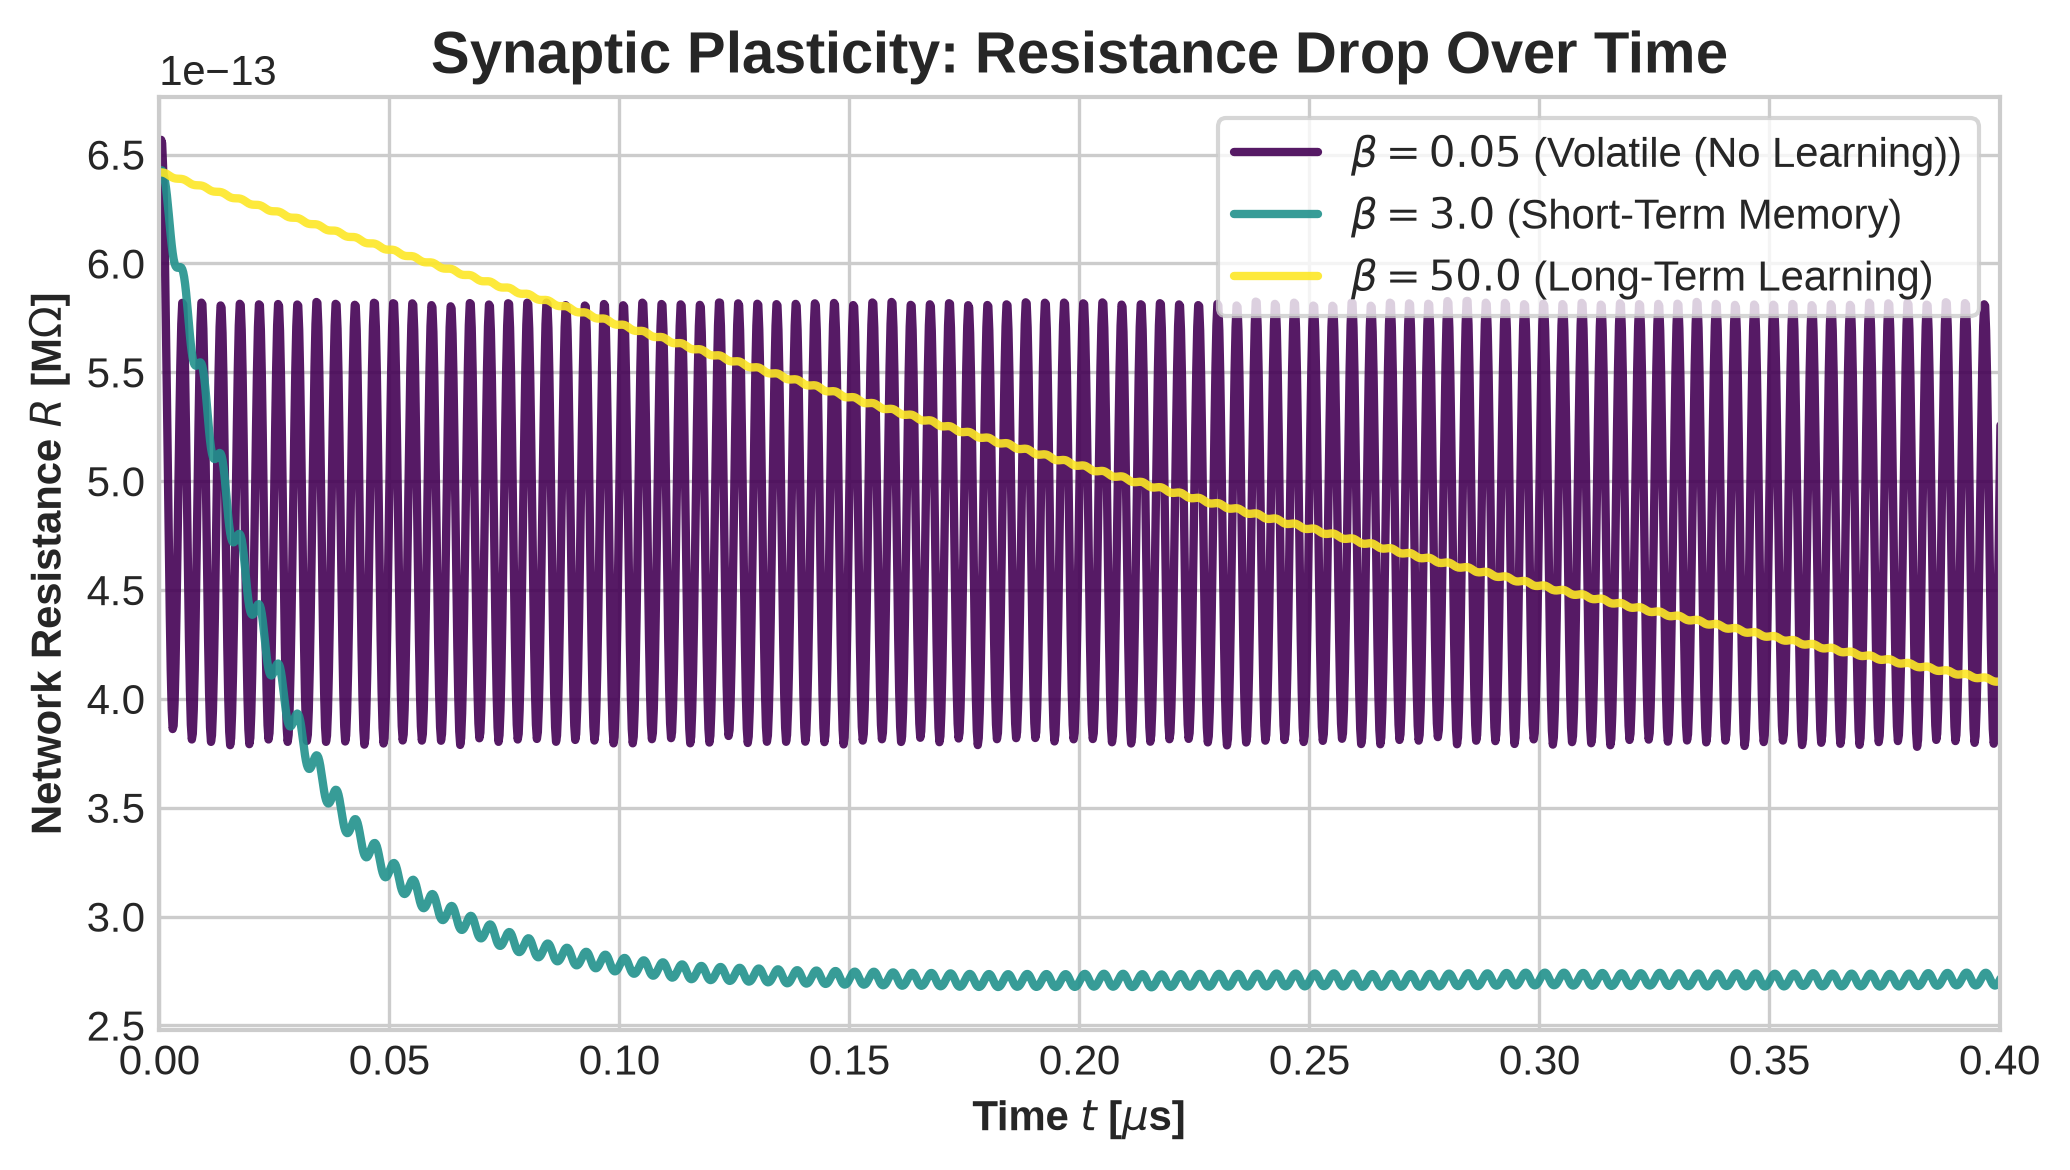

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

target_amp = 0.28  # Eine gute mittlere Amplitude für schöne Dynamiken
plot_betas = [0.05, 3.0, 50.0]
labels = ["Volatile (No Learning)", "Short-Term Memory", "Long-Term Learning"]
colors = ['#440154', '#21918c', '#fde725'] # Viridis-Farben per Hand für starken Kontrast

for beta, label, color in zip(plot_betas, labels, colors):
    df = data[target_amp][beta]
    time_us = df['t'].values * 1e6
    
    # 1. Glätten des Widerstands (Window=15, Polynom=3)
    R_smooth = savgol_filter(df['Resistance'].values, window_length=15, polyorder=3)
    
    ax.plot(time_us, R_smooth, label=rf"$\beta = {beta}$ ({label})", color=color, lw=2, alpha=0.9)

ax.set_xlabel(r"Time $t$ [$\mu$s]", weight='bold')
ax.set_ylabel(r"Network Resistance $R$ [M$\Omega$]", weight='bold')
ax.set_title("Synaptic Plasticity: Resistance Drop Over Time", size=14, weight='bold')
ax.legend(frameon=True, loc="upper right")
ax.set_xlim(0, 0.4) # Zoom auf die ersten 50% der Zeit, wo das meiste passiert
plt.tight_layout()
plt.show()

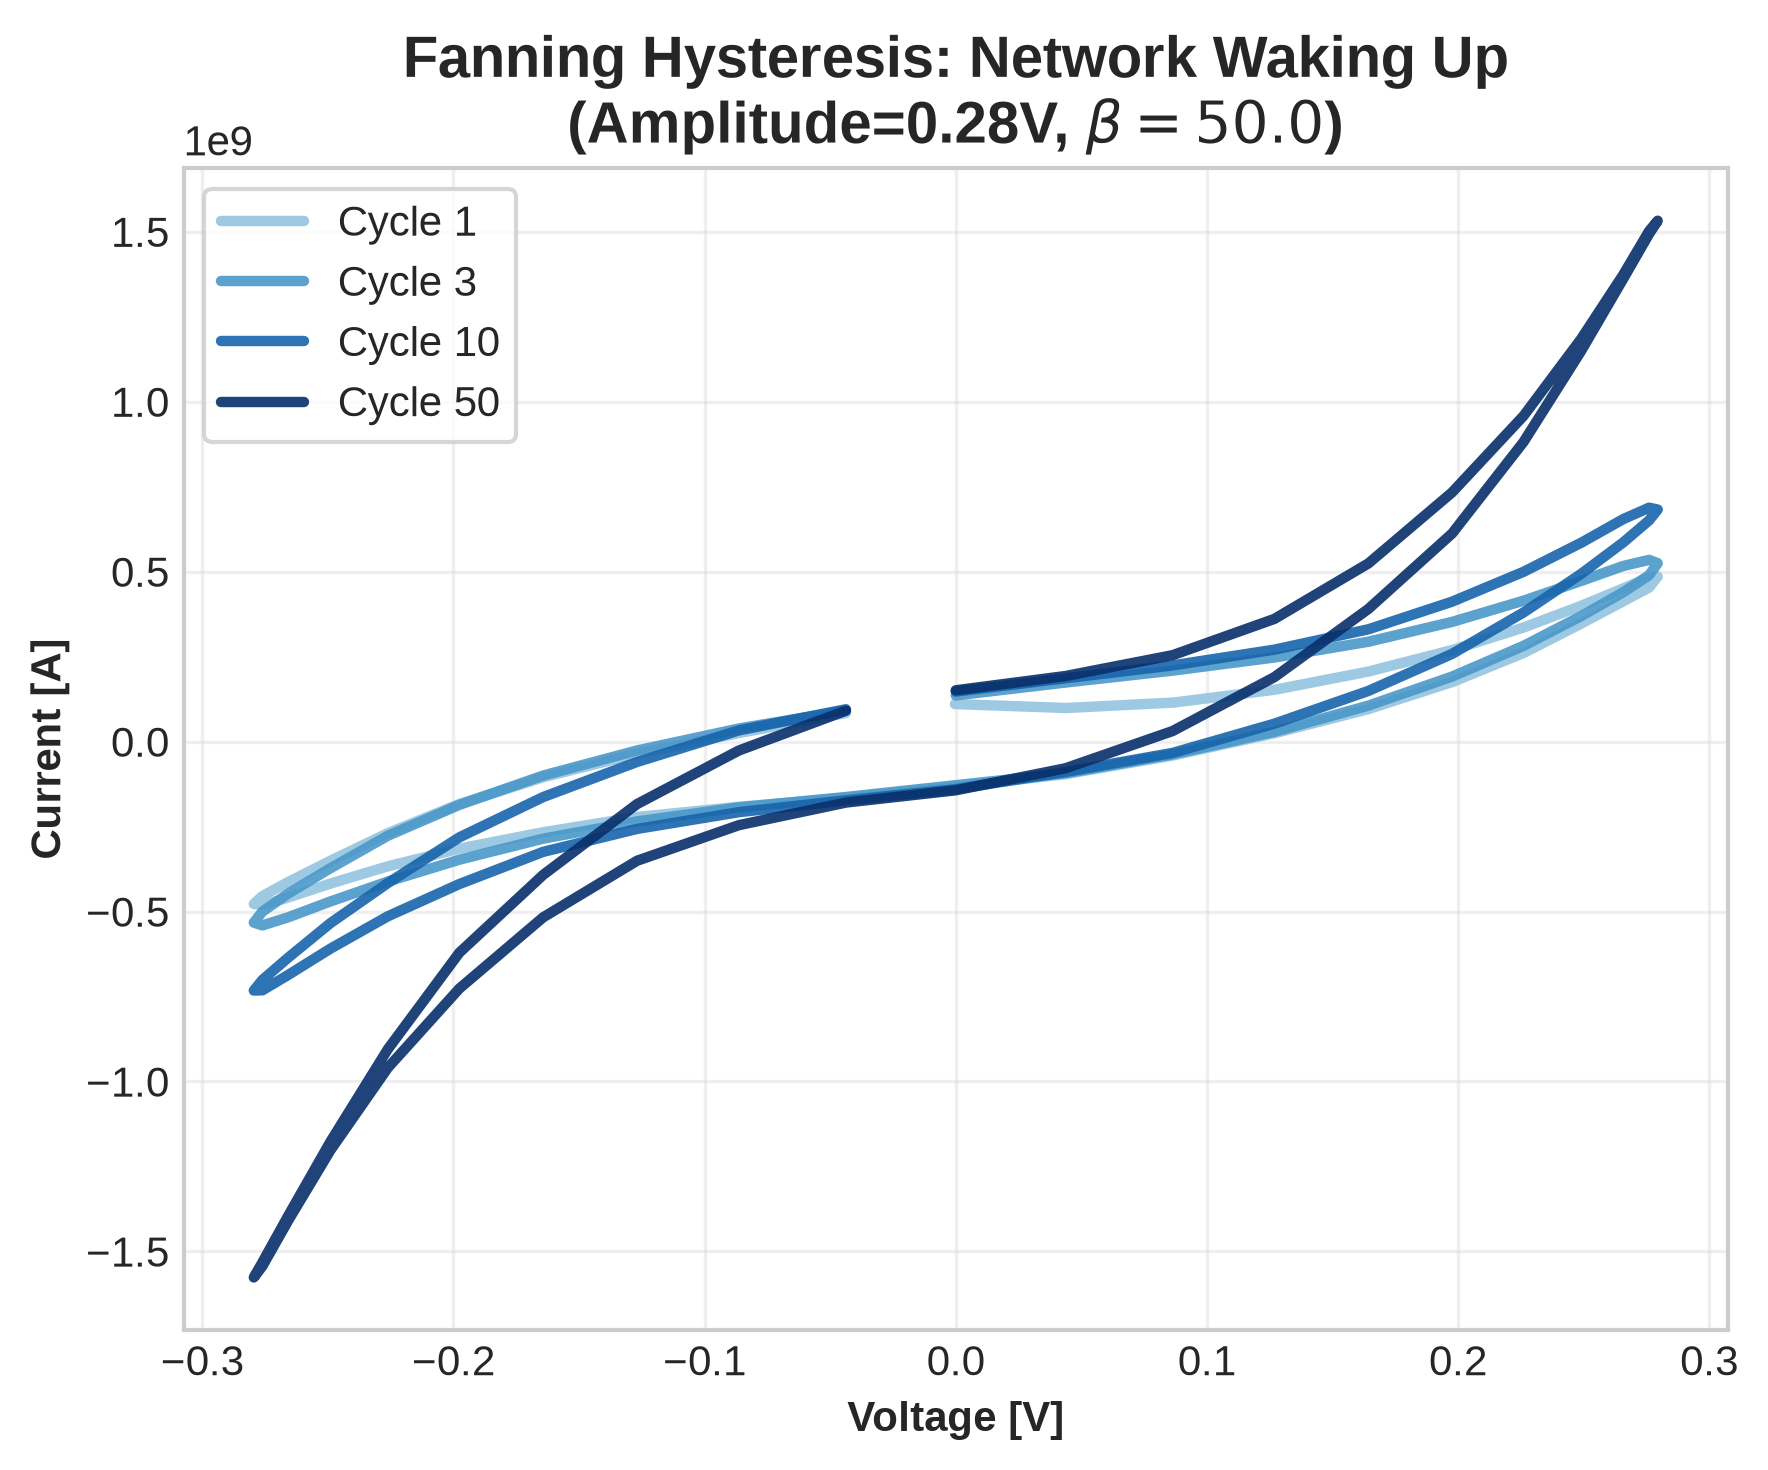

In [93]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

target_amp = 0.28
target_beta = 50.0  # System mit starkem Lerneffekt
df = data[target_amp][target_beta]

# Glätte auch Spannung und Strom für ein absolut sauberes Poster-Bild
V_smooth = savgol_filter(df['E0'].values, 11, 3)
I_smooth = savgol_filter(df['Total'].values, 15, 3)

steps_per_period = 40
# Wir picken uns 4 repräsentative Perioden raus (Start, Mitte, Ende)
periods_to_plot = [0, 2, 9, 49] 
cmap = plt.cm.Blues # Farbverlauf von Hellblau (Start) zu Dunkelblau (Gelernt)

for idx, p in enumerate(periods_to_plot):
    start = p * steps_per_period
    end = (p + 1) * steps_per_period
    
    # Farbe aus der Colormap (startet nicht ganz bei 0, damit es nicht unsichtbar weiß ist)
    color = cmap(0.4 + 0.6 * (idx / (len(periods_to_plot)-1))) 
    
    ax.plot(V_smooth[start:end], I_smooth[start:end], 
            color=color, lw=2.5, alpha=0.9, 
            label=f"Cycle {p+1}")

ax.set_xlabel("Voltage [V]", weight='bold')
ax.set_ylabel("Current [A]", weight='bold')
ax.set_title(f"Fanning Hysteresis: Network Waking Up\n(Amplitude={target_amp}V, $\\beta={target_beta}$)", size=14, weight='bold')
ax.legend(frameon=True, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()